In [1]:
import stim
import itertools
import numpy as np
import pickle
import time
import os
import re
import pprint
import numpy as np


from autqec.automorphisms   import *
from autqec.utils.qec       import *
from autqec.utils.qiskit    import *
from autqec.graph_auts      import *
from autqec.ZX_dualities    import *
from autqec.ZY_dualities    import *
from autqec.magma_interface import *
from autqec.code_embedding  import *
from magma_online           import *
from stim_helpers           import *
from compare_circuits       import *


# 5-qubit code [[5,1,3]]

### In $F_2$

- Hilbert space dimension: $2^5$
- Stabilizer generators: $n-k = 4$
    - $S = \langle XZZXI,\ IXZZX,\ XIXZZ,\ ZXIXZ \rangle$
- Logical subspace dimension: $2^k = 2$
- The stabilizers commute (equivalent to classical self-orthogonality).


### In $GF(4)$
- Using the CRSS mapping, The code lives in $GF(4)^5$
- As an additive code: $|C| = 2^{n-k} = 16$
- The code is actually linear over $GF(4)$: $[5,2]_{GF(4)}$
- Therefore it has **2 generating vectors**.
- The code is cyclic, so it can be described by a single generator polynomial $g(x) = 1 + \omega x + \omega x^2 + x^3$
    - The code is the ideal $C = \langle g(x) \rangle \subset GF(4)[x]/(x^5-1)$
    - Since $\deg g = 3$, the vector-space dimension is $5-\deg g = 2$
    - A convenient GF(4) basis is $g(x),\quad xg(x)$


# Two combined 5-qubit codes [[10,2,3]]

The two-block code is the direct sum

$$C \oplus C = \{(u,v): u \in C,\ v \in C\} \subset GF(4)^{10}. $$

Let $ g = (1,\omega,\omega,1,0)$ and $xg = (0,1,\omega,\omega,1)$. The direct-sum code has generators

- $(0,g)$
- $(0,xg)$
- $(g,0)$
- $(xg,0)$

Because each block is a $[5,2]_{GF(4)}$ code, the combined code is $[10,4]_{GF(4)}.$

This code is **not cyclic**, since cyclic shifts mix the two blocks.


## Automorphisms in the GF(4) description of stabilizer codes

### GF(4) representation
Using the CRSS mapping

| Pauli | GF(4) |
|---|---|
| I | 0 |
| X | 1 |
| Z | ω |
| Y | ω² |

a stabilizer code can be viewed as a classical code $C \subset GF(4)^n$. Automorphisms are transformations that map the code to itself.

### Local GF(4) symmetries — $S_3$
At each coordinate we can permute the non-zero elements $\{1,\omega,\omega^2\}$. These permutations form the group $S_3$ and are generated by multiplication by $\omega$ and conjugation:
- $x \mapsto \omega x$ giving $1 \to \omega \to \omega^2 \to 1$
- $x \mapsto x^2$ swapping $\omega \leftrightarrow \omega^2$

Together they generate all six permutations of $(1,\omega,\omega^2)$. In Pauli language this corresponds to permuting $X,Y,Z$.

### Coordinate permutations — $S_n$
We can also permute the $n$ coordinates (qubits):
$(c_1,c_2,\dots,c_n) \rightarrow (c_{\pi(1)},c_{\pi(2)},\dots,c_{\pi(n)})$
for any $\pi \in S_n$.

### Full transformation group
Combining local $S_3$ actions on each coordinate with coordinate permutations gives
$$G_n = S_3 \wr S_n$$
(the wreath product). Its size is
$$|G_n| = 6^n n!$$

### Automorphisms of a specific code
Only a subset of $G_n$ preserves a given code: $Aut(C) \subset G_n$. These are the code automorphisms.

### Example: the 5-qubit code
The $[[5,1,3]]$ code corresponds to the GF(4) code $[5,2]_{GF(4)}$ generated by $g(x)=1+\omega x+\omega x^2+x^3$. Although
$$|G_5| = 6^5 \cdot 5! = 933{,}120,$$
only $360$ transformations preserve the code, so
$$|Aut(C)| = 360.$$
This group is isomorphic to
$$Aut(C) \cong A_6.$$

### Meaning for quantum codes
If $U$ is an automorphism then $USU^\dagger = S$, so the stabilizer group is preserved and the encoded space is unchanged. Therefore automorphisms induce logical Clifford gates on the encoded qubits.

In [2]:
generators_5qubits = [
    stim.PauliString("XZZXI"),
    stim.PauliString("IXZZX"),
    stim.PauliString("XIXZZ"),
    stim.PauliString("ZZXIX")
]

# logical operators
logical_I = stim.PauliString("IIIII")
logical_X = stim.PauliString("XXXXX")
logical_Z = stim.PauliString("ZZZZZ")
logical_Y = canonicalize_real_pauli(logical_X * logical_Z)

logical_X_min = stim.PauliString("-YIXIY")
logical_Z_min = stim.PauliString("-XIZIX")
logical_Y_min = canonicalize_real_pauli(logical_X_min * logical_Z_min)

logical_basis5 = {
    "X": canonicalize_real_pauli(logical_X_min),
    "Y": canonicalize_real_pauli(logical_Y_min),
    "Z": canonicalize_real_pauli(logical_Z_min)
}

In [3]:
combined_generators = []
for s in generators_5qubits:
    combined_generators.append(s+logical_I)
    combined_generators.append(logical_I+s)

logical_XI = logical_X_min + logical_I
logical_ZI = logical_Z_min + logical_I
logical_IX = logical_I + logical_X_min
logical_IZ = logical_I + logical_Z_min
logical_XX = logical_X_min + logical_X_min
logical_ZZ = logical_Z_min + logical_Z_min
logical_XZ = logical_X_min + logical_Z_min
logical_ZX = logical_Z_min + logical_X_min
logical_YI = logical_XI * logical_ZI
logical_IY = logical_IX * logical_IZ
logical_YX = logical_YI * logical_IX
logical_YZ = logical_YI * logical_IZ
logical_XY = logical_XI * logical_IY
logical_ZY = logical_ZI * logical_IY
logical_YY = logical_YI * logical_IY

logical_basis = {
    "XI": canonicalize_real_pauli(logical_XI),
    "YI": canonicalize_real_pauli(logical_XI * logical_ZI),
    "ZI": canonicalize_real_pauli(logical_ZI),

    "IX": canonicalize_real_pauli(logical_IX),
    "IY": canonicalize_real_pauli(logical_IX * logical_IZ),
    "IZ": canonicalize_real_pauli(logical_IZ),

    "XX": canonicalize_real_pauli(logical_XI * logical_IX),
    "XY": canonicalize_real_pauli(logical_XI * logical_IY),
    "XZ": canonicalize_real_pauli(logical_XI * logical_IZ),

    "YX": canonicalize_real_pauli(logical_YI * logical_IX),
    "YY": canonicalize_real_pauli(logical_YI * logical_IY),
    "YZ": canonicalize_real_pauli(logical_YI * logical_IZ),

    "ZX": canonicalize_real_pauli(logical_ZI * logical_IX),
    "ZY": canonicalize_real_pauli(logical_ZI * logical_IY),
    "ZZ": canonicalize_real_pauli(logical_ZI * logical_IZ),
}

print_combined_stabilizers(combined_generators, 
                           "Combined generators: two blocks of [[5,1,3]] -> [[10,2,3]]")



Combined generators: two blocks of [[5,1,3]] -> [[10,2,3]]
+XZZXIIIIII   +IIIIIXZZXI
+IXZZXIIIII   +IIIIIIXZZX
+XIXZZIIIII   +IIIIIXIXZZ
+ZZXIXIIIII   +IIIIIZZXIX



In [4]:
prologue = stim.Circuit()
prologue.append("I", [i for i in range(10)])
prologue.append("H", [0])
prologue.append("S", [0])
prologue.append("Y", [2])
prologue.append("H", [4])
prologue.append("S", [4])
prologue.append("H", [5])
prologue.append("S", [5])
prologue.append("Y", [7])
prologue.append("H", [9])
prologue.append("S", [9])
# prologue.append("CZ", [0,5])
# prologue.append("CZ", [2,7])
# prologue.append("CZ", [4,9])
# prologue.append("CZ", [0,9])
# prologue.append("CZ", [2,5])
# prologue.append("CZ", [4,7])
# prologue.append("CZ", [0,7])
# prologue.append("CZ", [2,9])
# prologue.append("CZ", [4,5])

epilogue = stim.Circuit()



epilogue.append("I", [i for i in range(10)])

# epilogue.append("CZ", [0, 5])
# epilogue.append("CZ", [2, 7])
# epilogue.append("CZ", [4, 9])
# epilogue.append("CZ", [0,9])
# epilogue.append("CZ", [2,5])
# epilogue.append("CZ", [4,7])
# epilogue.append("CZ", [0,7])
# epilogue.append("CZ", [2,9])
# epilogue.append("CZ", [4,5])
epilogue.append("S", [0])
epilogue.append("S", [0])
epilogue.append("S", [0])
epilogue.append("H", [0])
epilogue.append("Y", [2])
epilogue.append("S", [4])
epilogue.append("S", [4])
epilogue.append("S", [4])
epilogue.append("H", [4])
epilogue.append("S", [5])
epilogue.append("S", [5])
epilogue.append("S", [5])
epilogue.append("H", [5])
epilogue.append("Y", [7])
epilogue.append("S", [9])
epilogue.append("S", [9])
epilogue.append("S", [9])
epilogue.append("H", [9])

combined_generators_after_prologue = [conjugate_stabilizer_by_circuit(s, prologue) 
                                      for s in combined_generators]
print_combined_stabilizers(combined_generators_after_prologue, 
                            "combined generators after prologue circuit: ")


combined generators after prologue circuit: 
-ZZZXIIIIII   -IIIIIZZZXI
-IXZZZIIIII   -IIIIIIXZZZ
-ZIXZYIIIII   -IIIIIZIXZY
-YZXIZIIIII   -IIIIIYZXIZ



In [5]:
nontrivial_autoqec_circuits = find_nontrivial_autoqec_circuits(
    combined_generators_after_prologue, n=10, k=2, d=3, 
    fileroot="./", verbose=True
)
print(nontrivial_autoqec_circuits[0])

Run the commands on MAGMA online calculator.
Copy and save output as 'magma_output_n10k2d3.txt'

number of automorphism generators = 11
Circuit (0) [('Z', 2), ('Z', 3), ('Z', 4), ('X', 5), ('Xsqrt', 1), ('S', 2), ('H', 3), ('H', 4), ('H', 5), ('SWAP', (4, 5))]
     Logical Action: [('S', 1)]
Circuit (1) [('GammaXYZ', 1), ('GammaXZY', 2), ('GammaXYZ', 3), ('GammaXYZ', 5), ('GammaXZY', 6), ('GammaXZY', 8), ('GammaXYZ', 9), ('GammaXZY', 10), ('SWAP', (5, 10)), ('SWAP', (4, 7)), ('SWAP', (3, 6)), ('SWAP', (2, 9)), ('SWAP', (1, 8))]
     Logical Action: [('H', 2), ('SWAP', (2, 1)), ('S', 2), ('Xsqrt', 1), ('Xsqrt', 2)]
Circuit (2) [('Z', 3), ('X', 5), ('H', 1), ('H', 2), ('H', 3), ('S', 4), ('Xsqrt', 5), ('SWAP', (1, 2))]
     Logical Action: [('S', 1)]
Circuit (4) [('Z', 8), ('S', 6), ('S', 7), ('H', 8), ('H', 9), ('H', 10), ('SWAP', (8, 9))]
     Logical Action: [('H', 2)]
Circuit (5) [('GammaXYZ', 1), ('GammaXYZ', 2), ('GammaXYZ', 3), ('GammaXYZ', 4), ('GammaXYZ', 5)]
     Logical Action

In [6]:
auto_circuit1 = autoqec_to_stim_circuit(nontrivial_autoqec_circuits[0])
auto_circuit1.append("I", [i for i in range(10)])
combined_generators_after_auto = [
    conjugate_stabilizer_by_circuit(s, auto_circuit1)
    for s in combined_generators_after_prologue
]


In [7]:
print_combined_stabilizers(combined_generators_after_prologue, 
                            "combined generators after prologue circuit: ")

print_combined_stabilizers(combined_generators_after_auto, 
                            "combined generators after auto_circuit1: ")

print("Check if auto circuit is automorphism of after prologue code:")
span_after_prologue = stabilizer_span(combined_generators_after_prologue)
for g in combined_generators_after_auto:
    print(str(g).replace("_", "I"), "YES" if str(g) in span_after_prologue else "NO")


combined generators after prologue circuit: 
-ZZZXIIIIII   -IIIIIZZZXI
-IXZZZIIIII   -IIIIIIXZZZ
-ZIXZYIIIII   -IIIIIZIXZY
-YZXIZIIIII   -IIIIIYZXIZ


combined generators after auto_circuit1: 
-YZXIZIIIII   -IIIIIZZZXI
-IYXXXIIIII   -IIIIIIXZZZ
-YIZYXIIIII   -IIIIIZIXZY
-ZZZXIIIIII   -IIIIIYZXIZ

Check if auto circuit is automorphism of after prologue code:
-YZXIZIIIII YES
-IIIIIZZZXI YES
-IYXXXIIIII YES
-IIIIIIXZZZ YES
-YIZYXIIIII YES
-IIIIIZIXZY YES
-ZZZXIIIIII YES
-IIIIIYZXIZ YES


# Pauli Sign Correction for Stabilizer Automorphisms

## Problem

Given stabilizer generators:

$$
\{g_i\}
$$

and their images under a Clifford circuit \( U \):

$$
g_i' = U g_i U^\dagger
$$

we often have:

- $\{g_i'\} $generates the **same stabilizer group**
- but $g_i' \neq g_i $(different basis + possible sign flips)

---

## Step 1 — Rebase (ignore phase)

Express each original generator as a product of the new ones:

$$
g_i \sim \prod_j (g_j')^{c_{ij}}
$$

This matches only the **Pauli body** (I/X/Y/Z), ignoring sign.

Define:

$$
\tilde{g}_i = \prod_j (g_j')^{c_{ij}}
$$

Then:

$$
\tilde{g}_i = (-1)^{s_i} g_i
$$

where \( s_i \in \{0,1\} \) is a sign mismatch.

---

## Step 2 — Effect of Pauli Conjugation

For any Pauli \( P \):

$$
P g P^\dagger =
\begin{cases}
+g & \text{if } [P, g] = 0 \\
-g & \text{if } \{P, g\} = 0
\end{cases}
$$

So conjugation flips the sign iff \( P \) **anticommutes** with \( g \).

---

## Step 3 — Symplectic Representation

Represent Pauli operators as binary vectors:

$$
g = (x \mid z), \quad P = (p_X \mid p_Z)
$$

The commutation relation is given by the **symplectic inner product**:

$$
\langle P, g \rangle = p_X \cdot z + p_Z \cdot x \;\; (\text{mod } 2)
$$

- \( 0 \Rightarrow \) commute  
- \( 1 \Rightarrow \) anticommute  

---

## Step 4 — Solve for Correction

We want a Pauli \( P \) such that:

$$
P \tilde{g}_i P^\dagger = g_i
$$

i.e. flip the sign exactly when needed:

$$
\langle P, \tilde{g}_i \rangle = s_i \quad (\text{mod } 2)
$$

---

## Step 5 — Linear System

Each generator gives one equation:

$$
p_X \cdot z_i + p_Z \cdot x_i = s_i
$$

Stacking all equations:

$$
A \cdot p = s
$$

where:

- \( p = (p_X \mid p_Z) \)
- \( A_i = (z_i \mid x_i) \)
- \( s_i = \) sign mismatch  

Solve over \( \mathbb{F}_2 \).

---

## Result

The solution gives a Pauli operator \( P \) such that:

$$
P\, \tilde{g}_i\, P^\dagger = g_i \quad \forall i
$$

---

## Key Insight

- Automorphisms preserve the **stabilizer group**, not your chosen generators  
- Differences = **basis change + sign flips**  
- Basis is handled by GF(2) linear algebra  
- Signs are fixed by a single global Pauli  

---

## One-line intuition

> Find a Pauli that anticommutes with exactly the generators that have the wrong sign.

In [8]:
pauli_correction = find_automorphism_pauli_correction(
    auto_gens = combined_generators_after_auto,
    orig_gens = combined_generators_after_prologue,
)
print("Pauli correction: ", str(pauli_correction).replace("_", "I"))

corrected_auto_circuit = auto_circuit1.copy()
corrected_auto_circuit += pauli_to_circuit(pauli_correction)

Pauli correction:  +IIIIIIIIII


In [9]:
combined_generators_after_corrected_auto = [conjugate_stabilizer_by_circuit(s, corrected_auto_circuit) 
                                      for s in combined_generators_after_prologue]

print_combined_stabilizers(combined_generators_after_prologue, 
                            "combined generators after prologue circuit: ")

print_combined_stabilizers(combined_generators_after_corrected_auto, 
                            "combined generators after corrected auto circuit: ")

print("Check if auto circuit is automorphism of after prologue code:")
span_after_prologue = stabilizer_span(combined_generators_after_prologue)
for g in combined_generators_after_corrected_auto:
    print(str(g).replace("_", "I"), "YES" if str(g) in span_after_prologue else "NO")



combined generators after prologue circuit: 
-ZZZXIIIIII   -IIIIIZZZXI
-IXZZZIIIII   -IIIIIIXZZZ
-ZIXZYIIIII   -IIIIIZIXZY
-YZXIZIIIII   -IIIIIYZXIZ


combined generators after corrected auto circuit: 
-YZXIZIIIII   -IIIIIZZZXI
-IYXXXIIIII   -IIIIIIXZZZ
-YIZYXIIIII   -IIIIIZIXZY
-ZZZXIIIIII   -IIIIIYZXIZ

Check if auto circuit is automorphism of after prologue code:
-YZXIZIIIII YES
-IIIIIZZZXI YES
-IYXXXIIIII YES
-IIIIIIXZZZ YES
-YIZYXIIIII YES
-IIIIIZIXZY YES
-ZZZXIIIIII YES
-IIIIIYZXIZ YES


In [10]:
combined_generators_after_epilogue = [conjugate_stabilizer_by_circuit(s, epilogue) 
                                      for s in combined_generators_after_corrected_auto]

print_combined_stabilizers(combined_generators, 
                            "original code stabalizors: ")

print_combined_stabilizers(combined_generators_after_epilogue, 
                            "combined generators after epilogue:")

print("Check if same span:")
original_span = stabilizer_span(combined_generators)
for g in combined_generators_after_epilogue:
    print(str(g).replace("_", "I"), "YES" if str(g) in original_span else "NO")



original code stabalizors: 
+XZZXIIIIII   +IIIIIXZZXI
+IXZZXIIIII   +IIIIIIXZZX
+XIXZZIIIII   +IIIIIXIXZZ
+ZZXIXIIIII   +IIIIIZZXIX


combined generators after epilogue:
+ZZXIXIIIII   +IIIIIXZZXI
+IYXXYIIIII   +IIIIIIXZZX
+ZIZYYIIIII   +IIIIIXIXZZ
+XZZXIIIIII   +IIIIIZZXIX

Check if same span:
+ZZXIXIIIII YES
+IIIIIXZZXI YES
+IYXXYIIIII YES
+IIIIIIXZZX YES
+ZIZYYIIIII YES
+IIIIIXIXZZ YES
+XZZXIIIIII YES
+IIIIIZZXIX YES


# Finding Logical Action

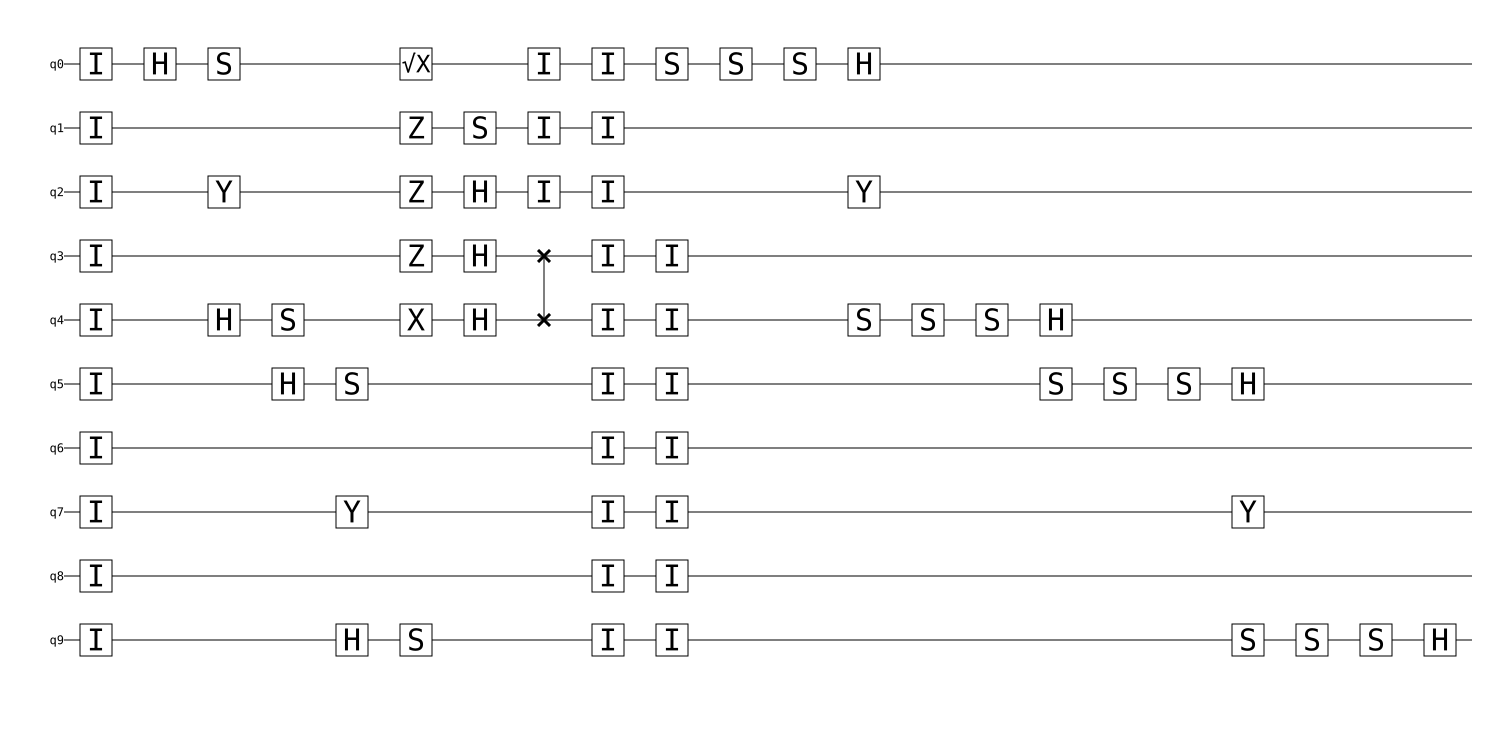

In [11]:
full_circuit = prologue + corrected_auto_circuit + epilogue
full_circuit.diagram("timeline-svg")

 Gate        |        before        |        after maps to
     XI      | +YIXIYIIIII            | -YI
     YI      | +ZIYIZIIIII            | +XI
     ZI      | +XIZIXIIIII            | +ZI
     IX      | +IIIIIYIXIY            | +IX
     IY      | +IIIIIZIYIZ            | +IY
     IZ      | +IIIIIXIZIX            | +IZ
     XX      | +YIXIYYIXIY            | -YX
     XY      | +YIXIYZIYIZ            | -YY
     XZ      | +YIXIYXIZIX            | -YZ
     YX      | +ZIYIZYIXIY            | +XX
     YY      | +ZIYIZZIYIZ            | +XY
     YZ      | +ZIYIZXIZIX            | +XZ
     ZX      | +XIZIXYIXIY            | +ZX
     ZY      | +XIZIXZIYIZ            | +ZY
     ZZ      | +XIZIXXIZIX            | +ZZ


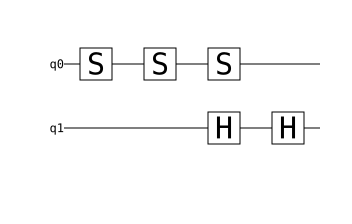

In [12]:
mapping = get_logical_action_map(
    logicals_dict   = logical_basis,
    circuit         = full_circuit,
    stabilizers     = combined_generators_after_epilogue,
    verbose         = True
)

logical_circuit = logical_map_to_tableau_circuit(mapping)
logical_circuit.diagram("timeline-svg")

8


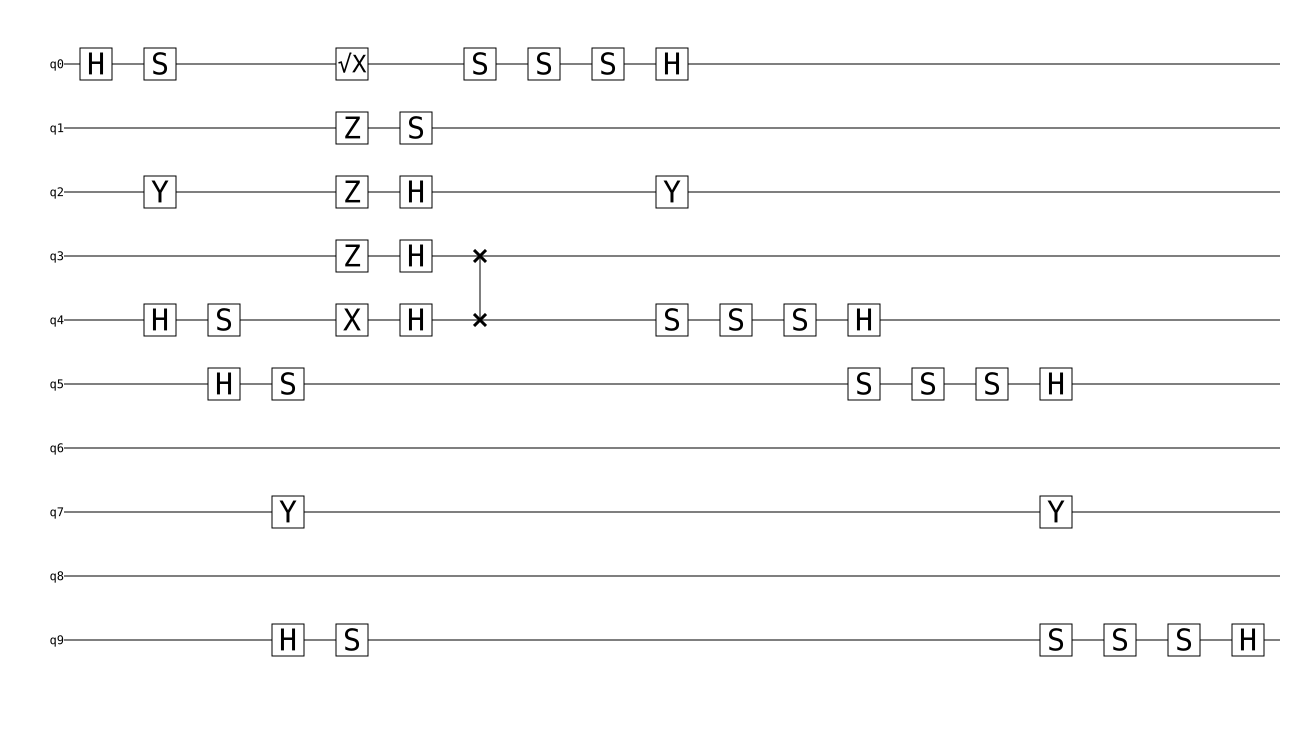

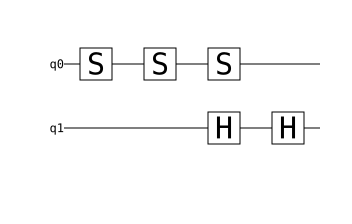

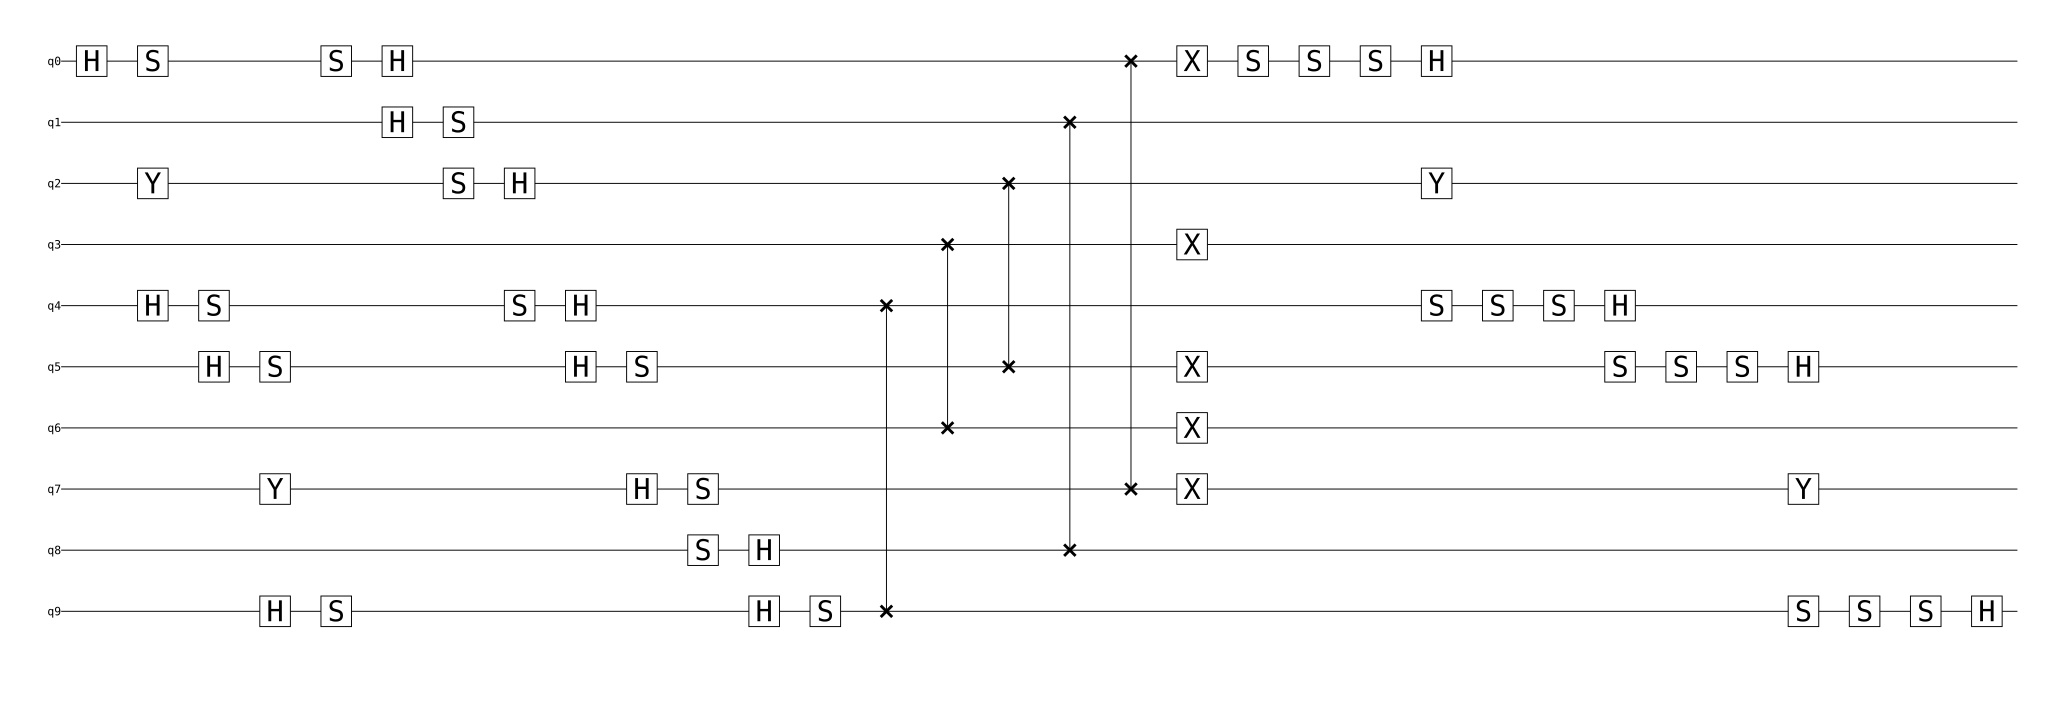

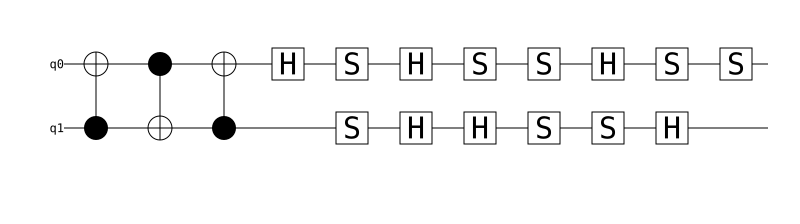

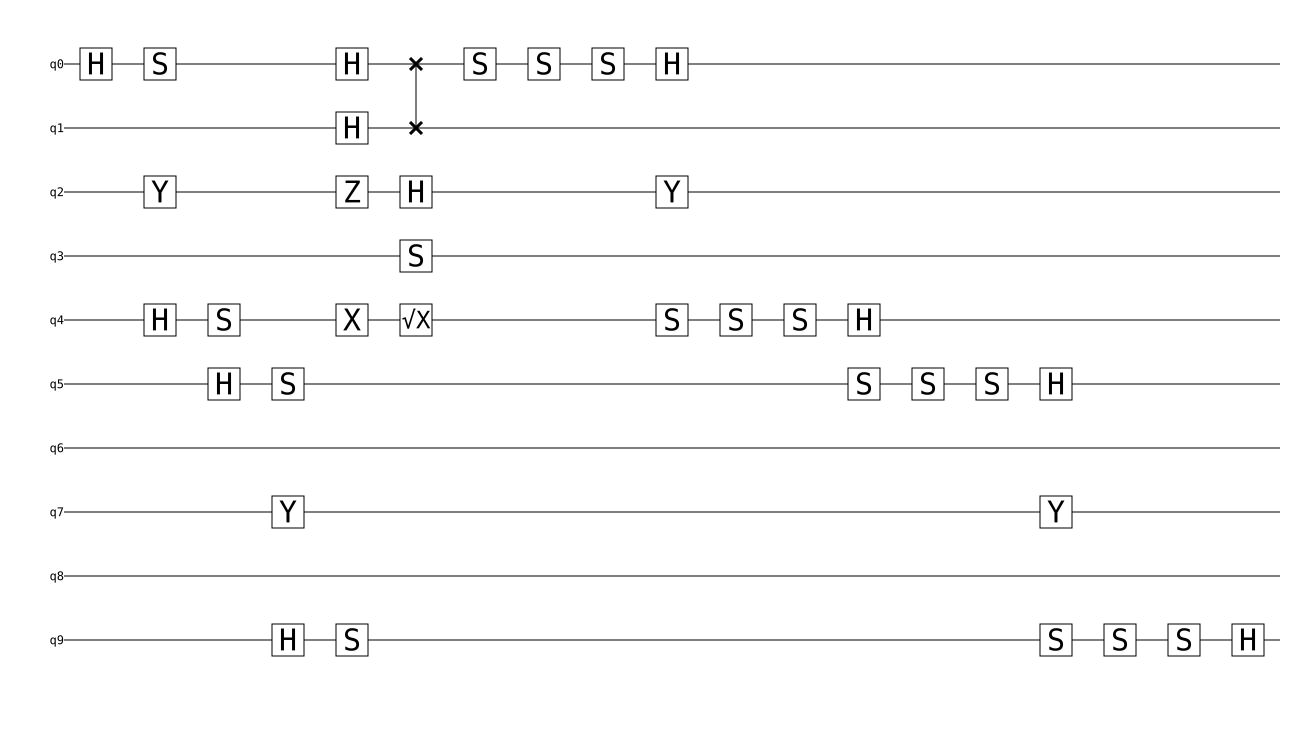

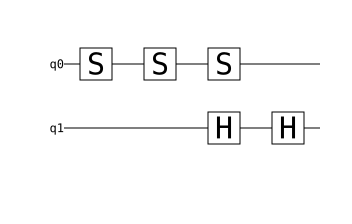

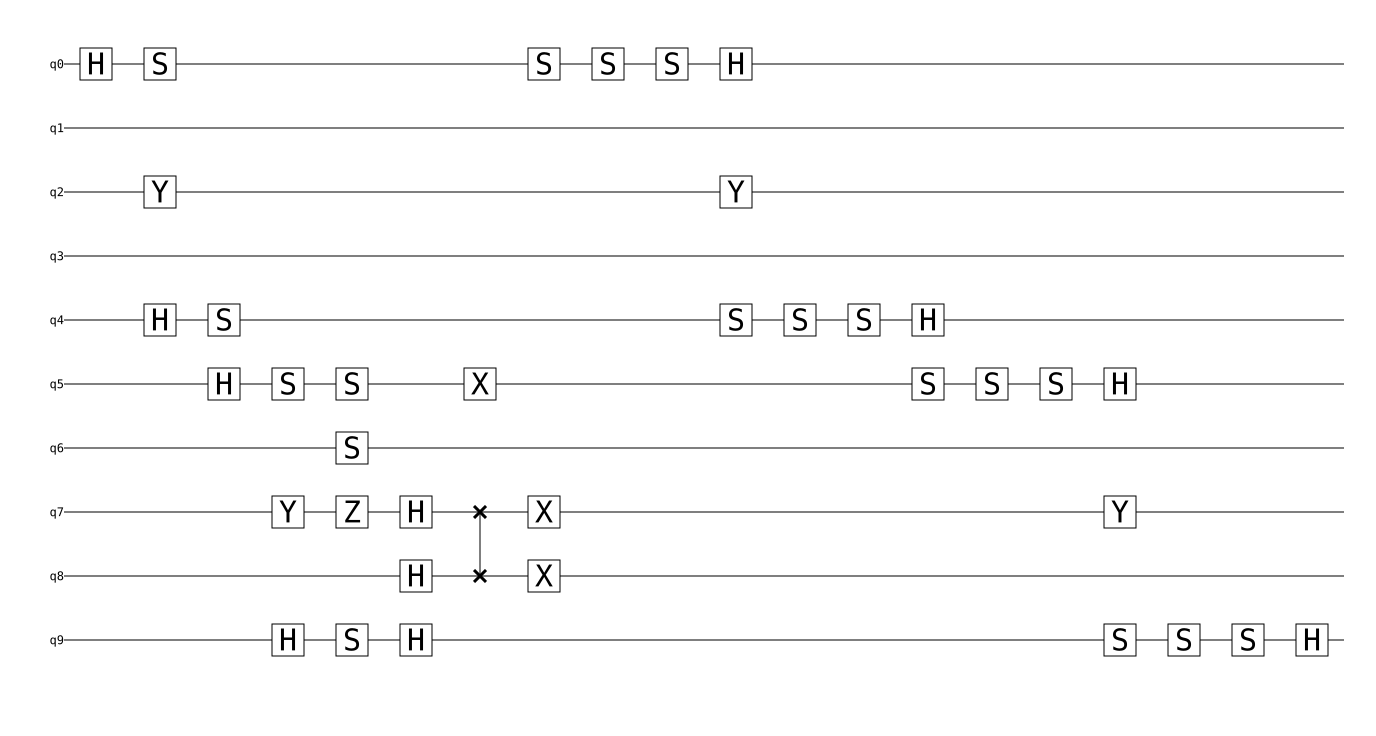

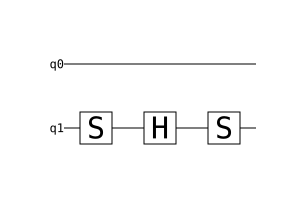

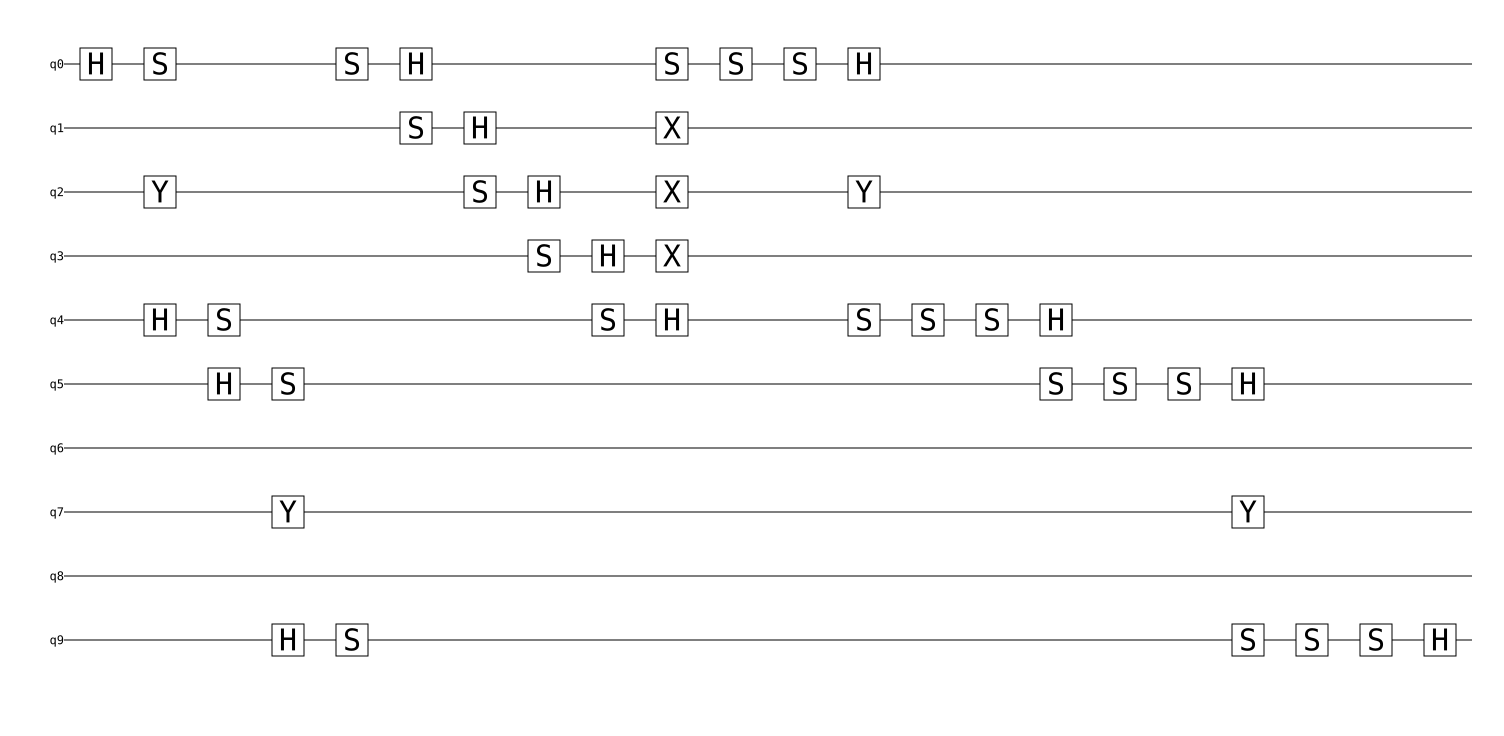

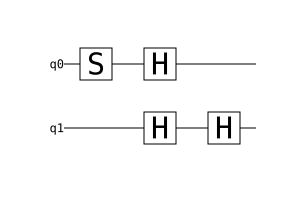

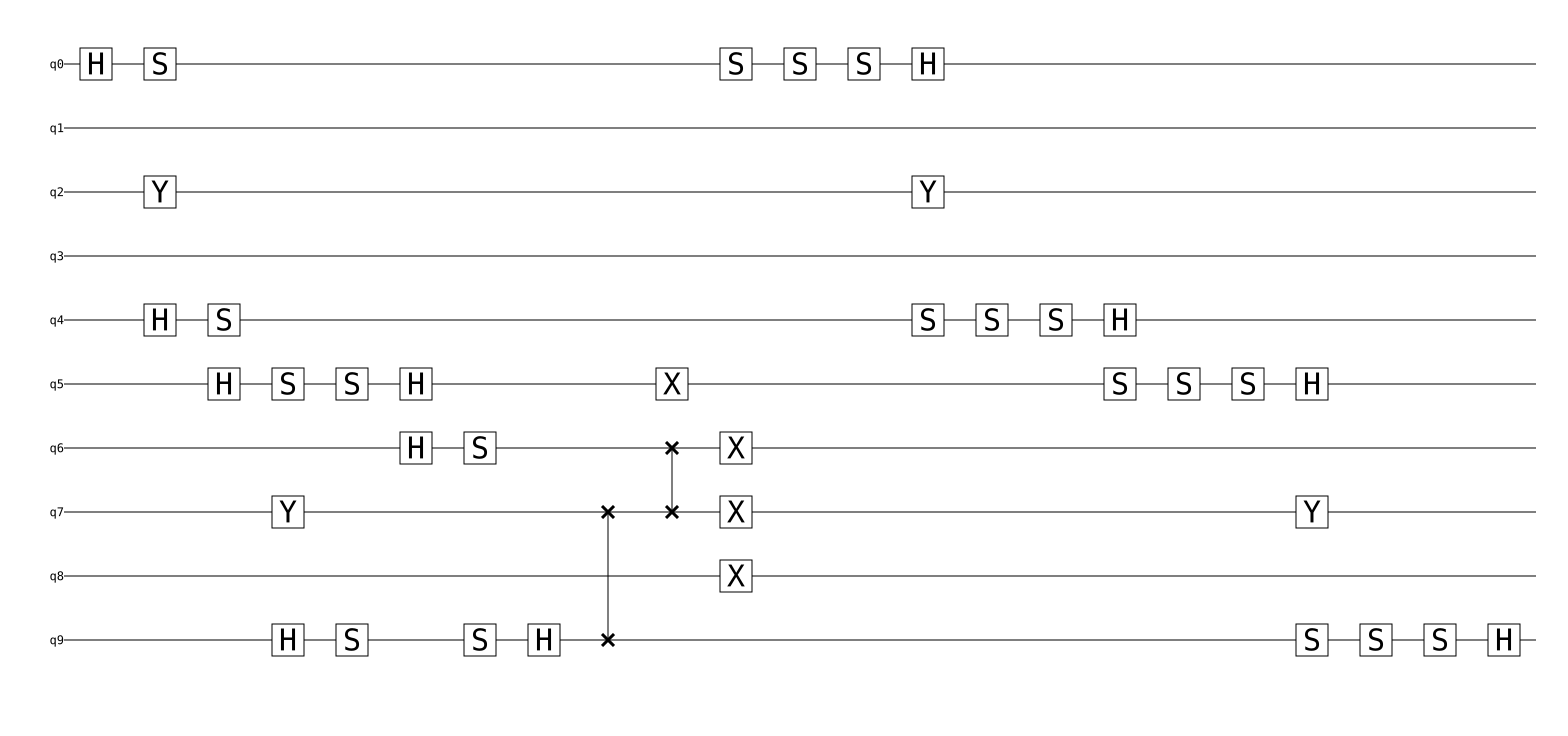

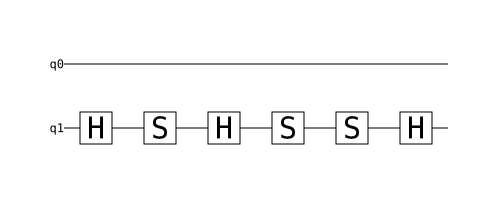

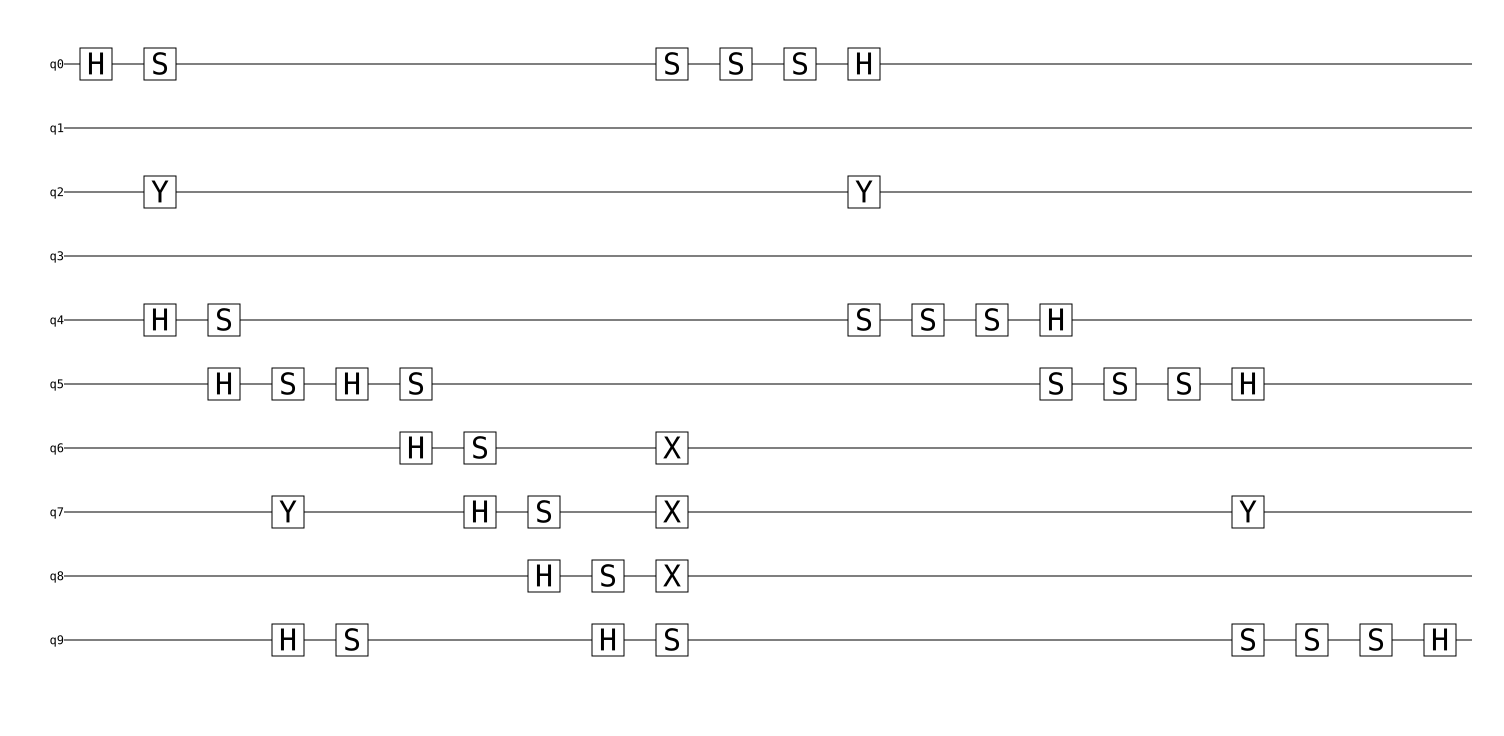

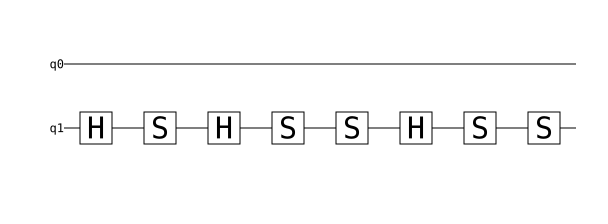

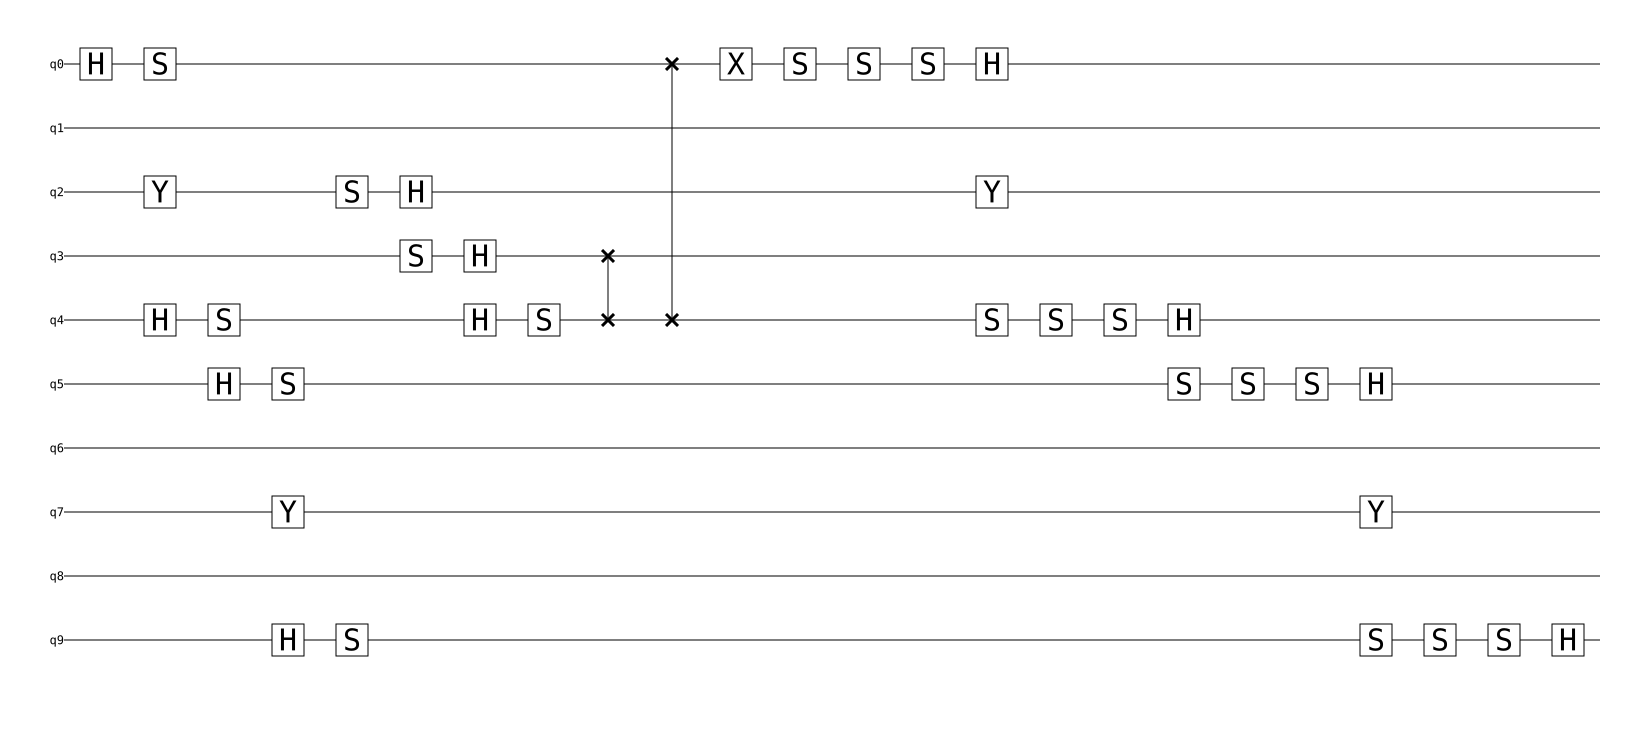

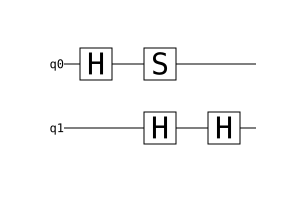

In [13]:
print(len(nontrivial_autoqec_circuits))

physical_circuits_found = []
logical_circuits_found = []

for circ in nontrivial_autoqec_circuits:
    auto_circuit1 = autoqec_to_stim_circuit(circ)
    auto_circuit1.append("I", [i for i in range(10)])

    combined_generators_after_auto = [
        conjugate_stabilizer_by_circuit(s, auto_circuit1)
        for s in combined_generators_after_prologue
    ]

    pauli_correction = find_automorphism_pauli_correction(
        auto_gens = combined_generators_after_auto,
        orig_gens = combined_generators_after_prologue,
    )

    corrected_auto_circuit = auto_circuit1.copy()
    corrected_auto_circuit += pauli_to_circuit(pauli_correction)


    combined_generators_after_corrected_auto = [conjugate_stabilizer_by_circuit(s, corrected_auto_circuit) 
                                        for s in combined_generators_after_prologue]

    combined_generators_after_epilogue = [conjugate_stabilizer_by_circuit(s, epilogue) 
                                        for s in combined_generators_after_corrected_auto]

    full_circuit = remove_identity_gates(prologue + corrected_auto_circuit + epilogue)
    physical_circuits_found.append(full_circuit)
    display(full_circuit.diagram("timeline-svg"))

    mapping = get_logical_action_map(
        logicals_dict   = logical_basis,
        circuit         = full_circuit,
        stabilizers     = combined_generators_after_epilogue
    )

    logical_circuit = logical_map_to_tableau_circuit(mapping)
    logical_circuits_found.append(logical_circuit)
    display(logical_circuit.diagram("timeline-svg"))

Any advantages?
Let's construct the logical circuit from 

<p align="center">
  <img src="H_logical.png" width="300">
  <img src="S_logical.png" width="300">
</p>


In [14]:
# from automorphism on 5-qubit code
H1_logical = [
    ("H", [0]),
    ("Z", [1]),
    ("H", [1]),
    ("Z", [2]),
    ("H", [2]),
    ("H", [3]),
    ("Y", [4]),
    ("H", [4]),
    ("SWAP", [3, 4]),
    ("SWAP", [2, 3]),
    ("SWAP", [1, 3]),

    # logical Y correction
    # ("Z", [0]),
    # ("Y", [2]),
    # ("Z", [4]),
]

S1_logical = [("S", [0]), ("S", [1]), ("S", [2]), ("S", [3]), ("S", [4]),("SWAP", [3,4]), ("SWAP", [2,3]), ("SWAP", [1,3])]
H2_logical = [(gate[0], [q+5 for q in gate[1]]) for gate in H1_logical]
S2_logical = [(gate[0], [q+5 for q in gate[1]]) for gate in S1_logical]

# from peicable FT
CZ_logical = [
            # epilogue
            ("H", [0]),("S", [0]),("Y", [2]),("H", [4]),("S", [4]),
            ("H", [5]),("S", [5]),("Y", [7]),("H", [9]),("S", [9]),
            # roundrobin
            ("CZ", [0,5]),("CZ", [2,7]),("CZ", [4,9]),
            ("CZ", [0,9]),("CZ", [2,5]),("CZ", [4,7]),
            ("CZ", [0,7]),("CZ", [2,9]),("CZ", [4,5]),
            # epilogue
            ("S", [0]),("S", [0]),("S", [0]),("H", [0]),("Y", [2]),
            ("S", [4]),("S", [4]),("S", [4]),("H", [4]),("S", [5]),
            ("S", [5]),("S", [5]),("H", [5]),("Y", [7]),("S", [9]),
            ("S", [9]),("S", [9]),("H", [9]),

            # logical ZZ correction
            # ("Z", [i for i in range(10)])
]

confirm there work

In [15]:
H1_logical_circ = stim.Circuit()
for g in H1_logical:
    H1_logical_circ.append(*g)

generators_after_ccccc = [
    conjugate_stabilizer_by_circuit(s, H1_logical_circ)
    for s in generators_5qubits
]

for g in generators_after_ccccc:
    print(str(g).replace("_", "I"))

mapping_H1_logical = get_logical_action_map(
    logicals_dict=logical_basis5,
    circuit=H1_logical_circ,
    stabilizers=generators_5qubits,
    verbose=True,
)


+ZXIXZ
+IXZZX
+ZZXIX
+XZZXI
 Gate        |        before        |        after maps to
     X       | +YIXIY                 | -Z
     Y       | +ZIYIZ                 | -Y
     Z       | +XIZIX                 | -X


In [16]:
S1_logical_circ = stim.Circuit()
for g in S1_logical:
    S1_logical_circ.append(*g)

generators_after_ccccc = [
    conjugate_stabilizer_by_circuit(s, S1_logical_circ)
    for s in generators_5qubits
]

for g in generators_after_ccccc:
    print(str(g).replace("_", "I"))

mapping_manually = get_logical_action_map(
    logicals_dict=logical_basis5,
    circuit=S1_logical_circ,
    stabilizers=generators_5qubits,
    verbose=True,
)

+YZIZY
+IZYYZ
+YYZIZ
+ZYYZI
 Gate        |        before        |        after maps to
     X       | +YIXIY                 | +Y
     Y       | +ZIYIZ                 | -X
     Z       | +XIZIX                 | +Z




+XZZXIIIIII   +IIIIIXZZXI
+IXZZXIIIII   +IIIIIIXZZX
+XIXZZIIIII   +IIIIIXIXZZ
+ZZXIXIIIII   +IIIIIZZXIX

 Gate        |        before        |        after maps to
     XI      | +YIXIYIIIII            | -XZ
     YI      | +ZIYIZIIIII            | -YZ
     ZI      | +XIZIXIIIII            | +ZI
     IX      | +IIIIIYIXIY            | -ZX
     IY      | +IIIIIZIYIZ            | -ZY
     IZ      | +IIIIIXIZIX            | +IZ
     XX      | +YIXIYYIXIY            | +YY
     XY      | +YIXIYZIYIZ            | -YX
     XZ      | +YIXIYXIZIX            | -XI
     YX      | +ZIYIZYIXIY            | -XY
     YY      | +ZIYIZZIYIZ            | +XX
     YZ      | +ZIYIZXIZIX            | -YI
     ZX      | +XIZIXYIXIY            | -IX
     ZY      | +XIZIXZIYIZ            | -IY
     ZZ      | +XIZIXXIZIX            | +ZZ


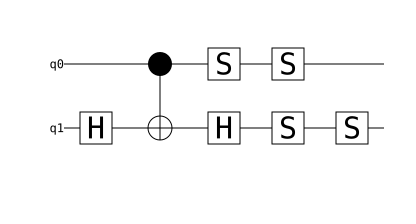

In [17]:
CZ_logical_circ = stim.Circuit()
for g in CZ_logical:
    CZ_logical_circ.append(*g)

generators_after_ccccc = [
    conjugate_stabilizer_by_circuit(s, CZ_logical_circ)
    for s in combined_generators
]

print_combined_stabilizers(generators_after_ccccc)

mapping_manually = get_logical_action_map(
                        logicals_dict   = logical_basis,
                        circuit         = CZ_logical_circ,
                        stabilizers     = combined_generators,
                        verbose         = True,
)
logical_circuit = logical_map_to_tableau_circuit(mapping_manually)
display(logical_circuit.diagram("timeline-svg"))

let's look at the last circuit

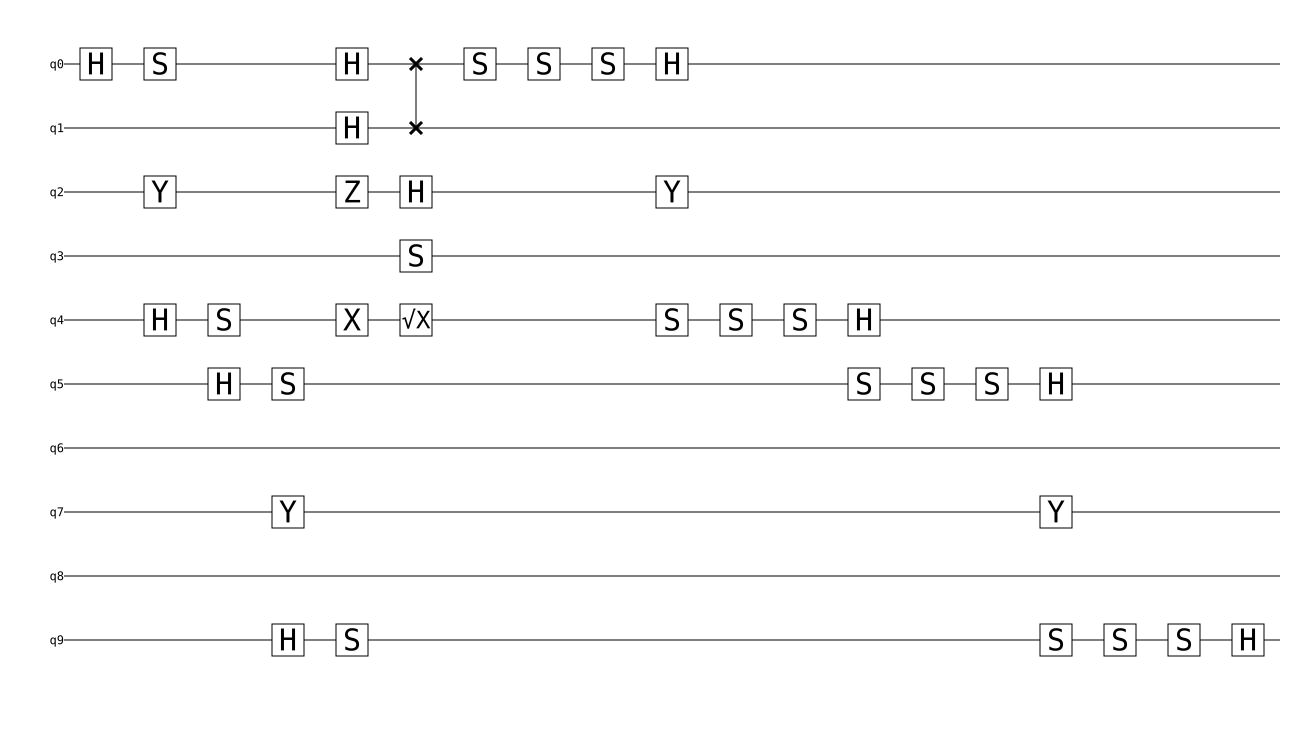

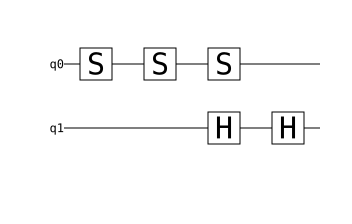

In [18]:
display(physical_circuits_found[2].diagram("timeline-svg"))
display(logical_circuits_found[2].diagram("timeline-svg"))

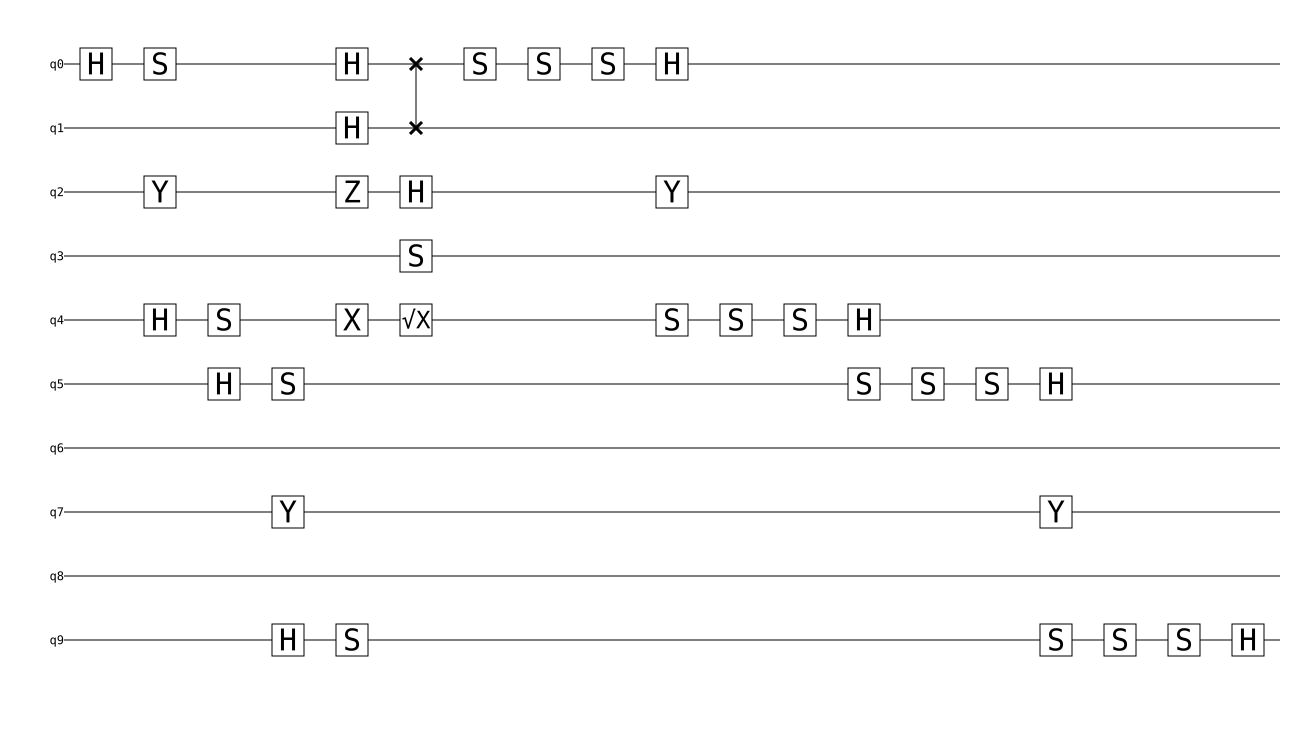

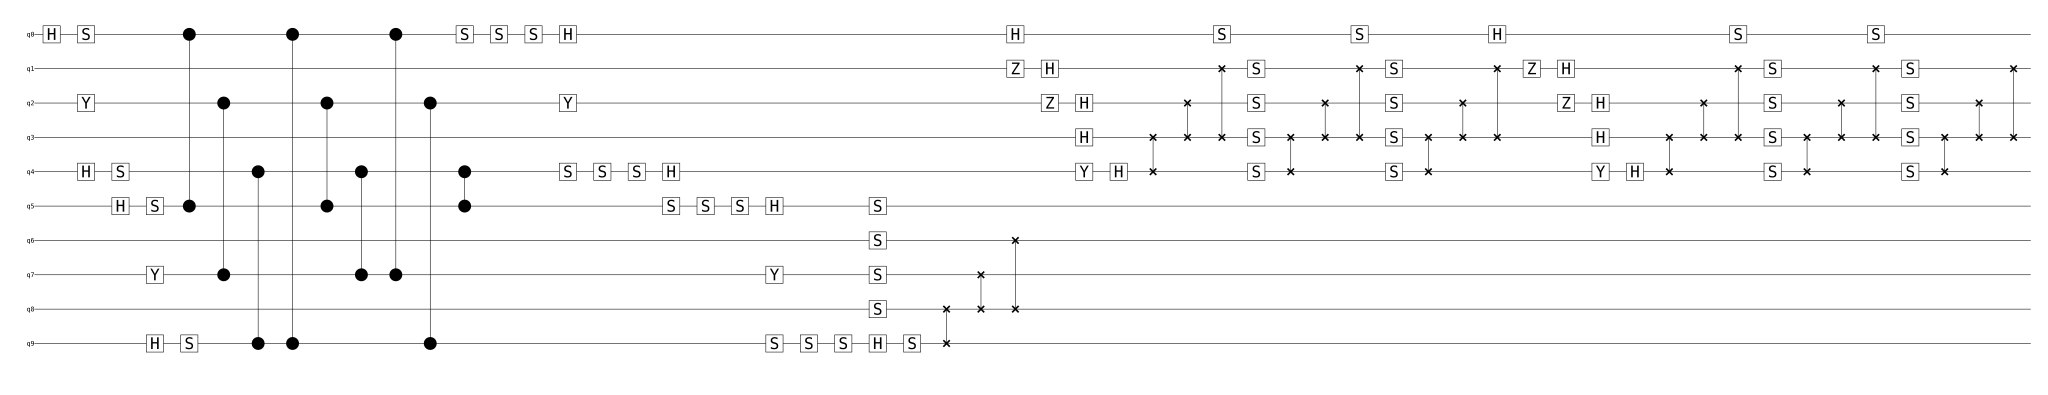

In [19]:
circ_constructed_auto     = physical_circuits_found[2]
circ_constructed_manually = stim.Circuit()

for g in CZ_logical:
    circ_constructed_manually.append(*g)

for g in S2_logical:
    circ_constructed_manually.append(*g)

for g in H1_logical:
    circ_constructed_manually.append(*g)
for g in S1_logical:
    circ_constructed_manually.append(*g)
for g in S1_logical:
    circ_constructed_manually.append(*g)

for g in H1_logical:
    circ_constructed_manually.append(*g)
for g in S1_logical:
    circ_constructed_manually.append(*g)
for g in S1_logical:
    circ_constructed_manually.append(*g)


display(circ_constructed_auto.diagram("timeline-svg"))
display(circ_constructed_manually.diagram("timeline-svg"))


These two should be equivalent

In [20]:
combined_generators_after_circ_constructed_auto = [conjugate_stabilizer_by_circuit(s, circ_constructed_auto) 
                                    for s in combined_generators]

combined_generators_after_circ_constructed_manually = [conjugate_stabilizer_by_circuit(s, circ_constructed_manually) 
                                    for s in combined_generators]
print_combined_stabilizers(combined_generators)
print_combined_stabilizers(combined_generators_after_circ_constructed_auto)
print_combined_stabilizers(combined_generators_after_circ_constructed_manually)


for g in combined_generators_after_circ_constructed_auto:
    if str(g) not in stabilizer_span(combined_generators):
        print(g, "NO")

for g in combined_generators_after_circ_constructed_manually:
    if str(g) not in stabilizer_span(combined_generators):
        print(g, "NO")

mapping_auto = get_logical_action_map(
    logicals_dict   = logical_basis,
    circuit         = circ_constructed_auto,
    stabilizers     = combined_generators_after_circ_constructed_auto,
    verbose=True
)

mapping_manually = get_logical_action_map(
    logicals_dict   = logical_basis,
    circuit         = circ_constructed_manually,
    stabilizers     = combined_generators_after_circ_constructed_manually,
    verbose=True
)




+XZZXIIIIII   +IIIIIXZZXI
+IXZZXIIIII   +IIIIIIXZZX
+XIXZZIIIII   +IIIIIXIXZZ
+ZZXIXIIIII   +IIIIIZZXIX



+YXXYIIIIII   +IIIIIXZZXI
+XIXZZIIIII   +IIIIIIXZZX
+IXZZXIIIII   +IIIIIXIXZZ
+YYZIZIIIII   +IIIIIZZXIX



+XIXZZIIIII   +IIIIIYZIZY
+IXZZXIIIII   +IIIIIIZYYZ
+XZZXIIIIII   +IIIIIYYZIZ
+ZXIXZIIIII   +IIIIIZYYZI

 Gate        |        before        |        after maps to
     XI      | +YIXIYIIIII            | -YI
     YI      | +ZIYIZIIIII            | +XI
     ZI      | +XIZIXIIIII            | +ZI
     IX      | +IIIIIYIXIY            | +IX
     IY      | +IIIIIZIYIZ            | +IY
     IZ      | +IIIIIXIZIX            | +IZ
     XX      | +YIXIYYIXIY            | -YX
     XY      | +YIXIYZIYIZ            | -YY
     XZ      | +YIXIYXIZIX            | -YZ
     YX      | +ZIYIZYIXIY            | +XX
     YY      | +ZIYIZZIYIZ            | +XY
     YZ      | +ZIYIZXIZIX            | +XZ
     ZX      | +XIZIXYIXIY            | +ZX
     ZY      | +XIZIXZIYIZ            | +ZY
    

Validating 'Circuit Constructed From Automorphism' is Clifford (pre-optimization)...
  ✓ Circuit Constructed From Automorphism is Clifford
Validating 'Circuit Constructed From Combining Logical Operators' is Clifford (pre-optimization)...
  ✓ Circuit Constructed From Combining Logical Operators is Clifford
Validating 'Circuit Constructed From Automorphism' is Clifford (post-optimization)...
  ✓ Circuit Constructed From Automorphism (optimized) is Clifford
Validating 'Circuit Constructed From Combining Logical Operators' is Clifford (post-optimization)...
  ✓ Circuit Constructed From Combining Logical Operators (optimized) is Clifford

  BEFORE -> AFTER OPTIMIZATION
  Metric                Circuit Constructed From Automorphism  Circuit Constructed From Combining Logical Operators
  ────────────────────  ─────────────────────────────────────  ────────────────────────────────────────────────────
  Depth                                8 -> 8                                     34 -> 16 (-1

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/qiskit/compiler/transpiler.py:276: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


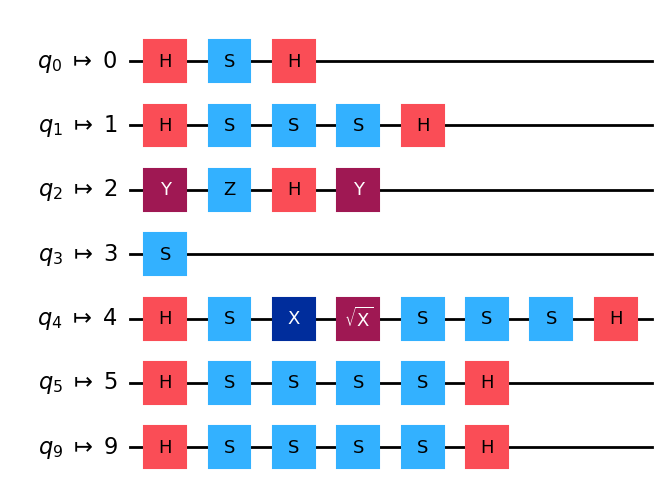

Circuit Constructed From Combining Logical Operators


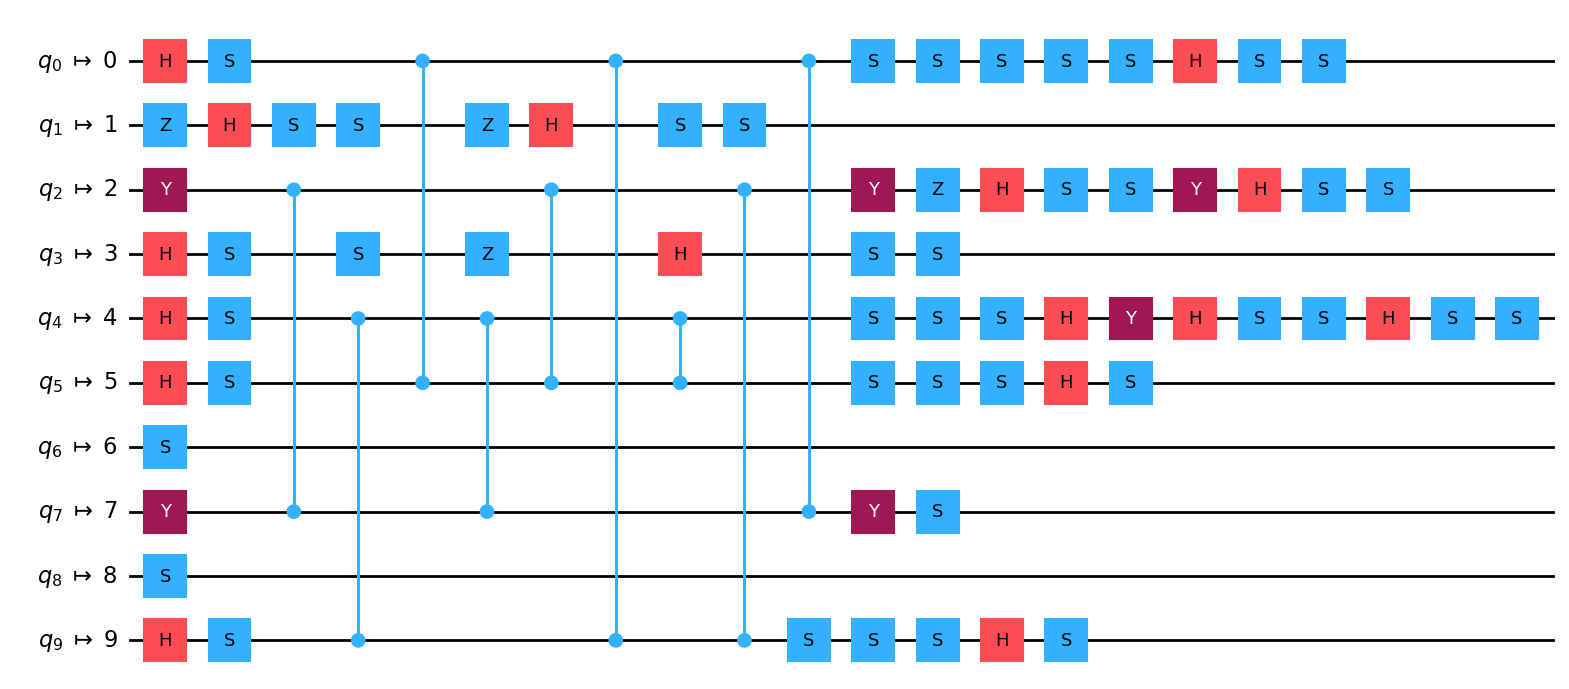

In [21]:
from qiskit.visualization import circuit_drawer

r = compare_circuits(
    circ_constructed_auto,
    circ_constructed_manually,
    name_a= "Circuit Constructed From Automorphism",
    name_b= "Circuit Constructed From Combining Logical Operators",
    optimization_level = 3,
    backend=None
)

print_results(r)


print("Circuit Constructed From Automorphism")
display(circuit_drawer(r["optimized_circuits"]["a"], output="mpl"))
print("Circuit Constructed From Combining Logical Operators")
display(circuit_drawer(r["optimized_circuits"]["b"], output="mpl"))


# Nested Search

In [22]:
# def make_cz_piece(pairs, n=10):
#     """
#     Make one prologue/epilogue piece from CZ pairs.
#     Since CZ is self-inverse, prologue == epilogue.
#     """
#     c = stim.Circuit()
#     c.append("I", list(range(n)))

#     for a, b in pairs:
#         c.append("CZ", [a, b])

#     return c


# def make_cz_pieces(list_of_pair_sets, n=10):
#     """
#     Input:
#         [
#             [(0,5), (2,7), (4,9)],
#             [(0,7), (2,9), (4,5)],
#             ...
#         ]

#     Returns:
#         prologues, epilogues
#     """
#     prologues = []
#     epilogues = []

#     for pairs in list_of_pair_sets:
#         piece = make_cz_piece(pairs, n=n)

#         prologues.append(piece)
#         epilogues.append(piece.copy())  # CZ inverse = itself

#     return prologues, epilogues

# cz_pair_sets = [
#     [(0, 5), (2, 7), (4, 9)],
#     [(0, 7), (2, 9), (4, 5)],
# ]

# prologues, epilogues = make_cz_pieces(cz_pair_sets, n=10)


In [23]:
# results = search_nested_pieceable_autos(
#     combined_generators=combined_generators,
#     logical_basis=logical_basis,
#     prologues=prologues,
#     epilogues=epilogues,
#     n=10,
#     k=2,
#     d=3,
#     fileroot="./",
#     verbose=True,
#     display_nodes=True,
# )